# Análisis de Negocio — Riesgo Crediticio, Préstamos e Hipotecas (Semana 2)

**Equipo:** Equip_32 — Analistas de Finanzas y Riesgo Crediticio  
**Dataset:** `2026-07-06_bank_dataset_transformed.csv` (+ exportación clusterizada para análisis complementario)  
**Notebooks previos:** EDA, Transformaciones de Datos, Clustering de Clientes

---

## Pregunta de negocio

> **¿Los clientes con préstamos personales e hipotecas tienden a tener un saldo medio más bajo o un mayor riesgo de impago? ¿Cómo debemos ajustar nuestras ofertas y estrategias de gestión de riesgos en función de estos hallazgos?**

### Enfoque analítico

1. Establecer la tasa base de impago del portfolio
2. **Analizar la exposición crediticia** (hipoteca, préstamo personal, combinada) vs saldo e impago
3. Comparar distribuciones de saldo entre clientes con y sin impago
4. Segmentar por niveles de saldo (estándar y extendido, incluyendo €3k–10k y > €10k)
5. Cruzar **saldo binario (≤ €500 vs > €500)** y **niveles extendidos** con exposición crediticia
6. Explorar segmentaciones transformadas (`age_group`, `job_profile`, `financial_burden_label`)
7. Vista complementaria por clusters (segmentos de identidad del cliente — para personalización de ofertas)
8. Validación estadística y recomendaciones de política crediticia


### Hipótesis

| | Enunciado |
|---|---|
| **H₀** | La exposición a productos crediticios (hipoteca / préstamo personal) es independiente del saldo de la cuenta y del impago crediticio. |
| **H₁** | Los clientes con hipoteca y/o préstamo personal tienen **saldos medios más bajos** y/o **mayor riesgo de impago** que los clientes sin estos productos. |


## 1. Configuración y carga de datos


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

import re

# Estilo visual (consistente con los notebooks del equipo)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

DATA_PATH = Path("../Data/2026-07-06_bank_dataset_transformed.csv")
CLUSTERED_PATH = Path("../Data/2026-07-06_bank_dataset_clustered.csv")

# Paleta de colores del equipo
COLORS = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]
PALETTE_DEFAULT = {"no": "#8DB79A", "yes": "#1F5C45"}

# Esquemas de segmentación de saldo
BALANCE_BINS_STANDARD = [-np.inf, 0, 500, 1500, 3000, np.inf]
BALANCE_LABELS_STANDARD = [
    "Negativo (≤ €0)", "€0–500", "€500–1.500", "€1.500–3.000", "> €3.000"
]

BALANCE_BINS_EXTENDED = [-np.inf, 0, 500, 1500, 3000, 10000, np.inf]
BALANCE_LABELS_EXTENDED = [
    "Negativo (≤ €0)", "€0–500", "€500–1.500", "€1.500–3.000",
    "€3.000–10.000", "> €10.000"
]

# Orden de exposición crediticia (etiquetas derivadas en español)
CREDIT_EXPOSURE_ORDER = [
    "Sin productos", "Solo hipoteca", "Solo préstamo personal", "Hipoteca + Préstamo personal"
]


In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Registros en el dataset transformado: {len(df_raw):,}")
df_raw.head()


Registros en el dataset transformado: 10,975


,id,age,job,marital,education,default,balance,housing,loan,contact,...,no_previous_contact,had_previous_contact,age_group,financial_burden,financial_burden_label,education_rank,education_label,job_profile,week_of_month,campaign_group
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,White Collar,1,0-3
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,2.0,Secondary,White Collar,1,0-3
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,1,0,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Blue Collar,1,0-3
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,3.0,Tertiary,White Collar,1,0-3


In [3]:
# Variables relevantes para la pregunta de negocio (nombres de columna originales)
ANALYSIS_COLS = [
    "id", "balance", "default", "loan", "housing", "age", "job",
    "age_group", "job_profile", "financial_burden_label"
]

df = df_raw[ANALYSIS_COLS].copy()
df["default_flag"] = (df["default"] == "yes").astype(int)

print(f"Muestra de análisis: {len(df):,} clientes")
print(f"Tasa global de impago: {df['default_flag'].mean():.2%}")
print(f"Número de impagos: {df['default_flag'].sum()}")


Muestra de análisis: 10,975 clientes
Tasa global de impago: 1.47%
Número de impagos: 161


In [4]:
def default_rate_table(data, group_col):
    """Calcula un resumen de tasa de impago por columna de agrupación.

    Parámetros
    ----------
    data : pandas.DataFrame
        Dataset con `default_flag` y la columna de agrupación.
    group_col : str
        Nombre de la columna para segmentar clientes.

    Devuelve
    --------
    pandas.DataFrame
        Resumen con recuento de clientes, impagos, tasa de impago y tasa (%).
    """
    summary = (
        data.groupby(group_col, observed=True)
        .agg(clientes=("default_flag", "count"),
             impagos=("default_flag", "sum"),
             tasa_impago=("default_flag", "mean"))
        .reset_index()
    )
    summary["tasa_impago_pct"] = (summary["tasa_impago"] * 100).round(2)
    return summary


def cross_default_rate(data, row_col, col_col):
    """Construye tablas pivote de tasas de impago y tamaños muestrales.

    Parámetros
    ----------
    data : pandas.DataFrame
        Dataset con `default_flag` y las dos columnas de agrupación.
    row_col : str
        Columna para las filas del pivote.
    col_col : str
        Columna para las columnas del pivote.

    Devuelve
    --------
    pivot_rate : pandas.DataFrame
        Tasa de impago por combinación fila/columna.
    pivot_n : pandas.DataFrame
        Tamaño muestral por combinación fila/columna.
    """
    grouped = (
        data.groupby([row_col, col_col], observed=True)
        .agg(tasa_impago=("default_flag", "mean"), n=("default_flag", "count"))
        .reset_index()
    )
    pivot_rate = grouped.pivot(index=row_col, columns=col_col, values="tasa_impago")
    pivot_n = grouped.pivot(index=row_col, columns=col_col, values="n")
    return pivot_rate, pivot_n


def assign_credit_exposure(data):
    """Crea una etiqueta de exposición crediticia a partir de `housing` y `loan`.

    Parámetros
    ----------
    data : pandas.DataFrame
        Dataset con columnas `housing` y `loan` (yes/no).

    Devuelve
    --------
    pandas.Series
        Etiqueta de exposición crediticia por cliente.
    """
    conditions = [
        (data["housing"] == "no") & (data["loan"] == "no"),
        (data["housing"] == "yes") & (data["loan"] == "no"),
        (data["housing"] == "no") & (data["loan"] == "yes"),
        (data["housing"] == "yes") & (data["loan"] == "yes"),
    ]
    labels = [
        "Sin productos", "Solo hipoteca", "Solo préstamo personal", "Hipoteca + Préstamo personal"
    ]
    return pd.Series(np.select(conditions, labels, default="Desconocido"), index=data.index)


def assign_balance_tier(data, bins, labels, col_name="balance_tier"):
    """Asigna etiquetas de nivel de saldo usando intervalos fijos de negocio.

    Parámetros
    ----------
    data : pandas.DataFrame
        Dataset con columna `balance`.
    bins : list
        Límites de intervalo para pandas.cut.
    labels : list
        Etiquetas de cada intervalo.
    col_name : str, optional
        Nombre de la columna de salida.

    Devuelve
    --------
    pandas.DataFrame
        Copia del dataset con la nueva columna de nivel de saldo.
    """
    out = data.copy()
    out[col_name] = pd.cut(out["balance"], bins=bins, labels=labels)
    return out


def odds_ratio_and_rr(group_a, group_b, label_a="Grupo A", label_b="Grupo B"):
    """Calcula el odds ratio y el riesgo relativo entre dos grupos de clientes.

    Parámetros
    ----------
    group_a, group_b : pandas.DataFrame
        Grupos de comparación con columna `default_flag`.
    label_a, label_b : str
        Nombres descriptivos de cada grupo.

    Devuelve
    --------
    pandas.DataFrame
        Resumen de una fila con tasas de impago, odds ratio y riesgo relativo.
    """
    a = group_a["default_flag"].sum()
    b = len(group_a) - a
    c = group_b["default_flag"].sum()
    d = len(group_b) - c

    odds_a = a / b if b > 0 else np.inf
    odds_b = c / d if d > 0 else np.inf
    or_value = odds_a / odds_b if odds_b > 0 else np.inf

    rate_a = a / len(group_a)
    rate_b = c / len(group_b)
    rr_value = rate_a / rate_b if rate_b > 0 else np.inf

    return pd.DataFrame({
        "comparacion": [f"{label_a} vs {label_b}"],
        f"tasa_impago_{label_a}": [f"{rate_a:.2%}"],
        f"tasa_impago_{label_b}": [f"{rate_b:.2%}"],
        "odds_ratio": [round(or_value, 2)],
        "riesgo_relativo": [round(rr_value, 2)],
    })


## 2. Tasa base de impago

Antes de segmentar, establecemos la **línea base del portfolio**: la proporción de clientes que han incurrido en impago crediticio.


In [5]:
default_summary = (
    df["default"]
    .value_counts()
    .rename_axis("default")
    .reset_index(name="clientes")
)
default_summary["tasa_impago"] = default_summary["clientes"] / default_summary["clientes"].sum()
default_summary


,default,clientes,tasa_impago
0,no,10814,0.98533
1,yes,161,0.01467


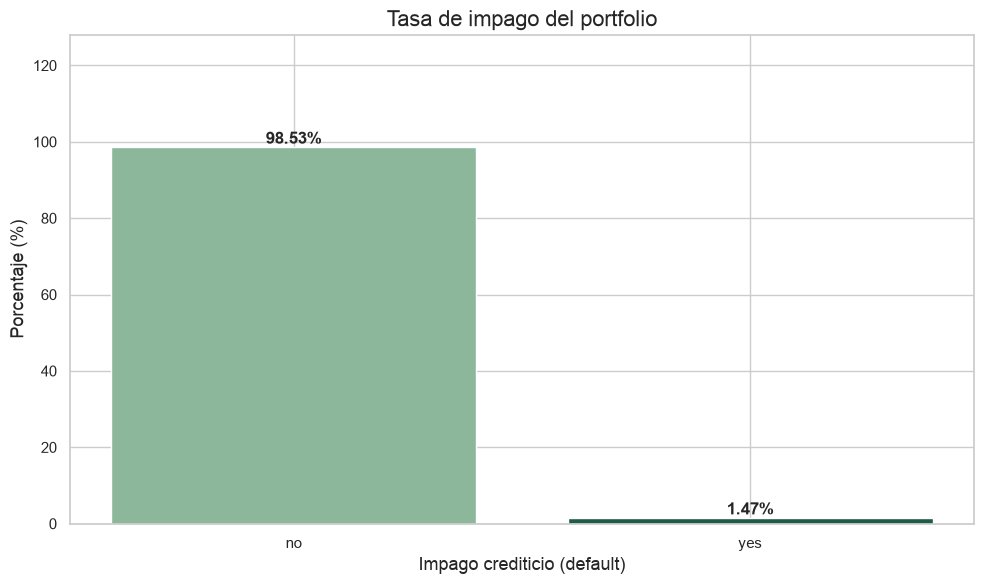

In [6]:
fig, ax = plt.subplots()
colors = ["#8DB79A", "#1F5C45", "#DDEFE6"]
bars = ax.bar(default_summary["default"], default_summary["tasa_impago"] * 100, color=colors)
ax.set_title("Tasa de impago del portfolio")
ax.set_xlabel("Impago crediticio (default)")
ax.set_ylabel("Porcentaje (%)")
ax.set_ylim(0, max(default_summary["tasa_impago"] * 100) * 1.3)

for bar, rate in zip(bars, default_summary["tasa_impago"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{rate:.2%}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


**Interpretación:** El impago sigue siendo un evento poco frecuente (~1,5% del portfolio). Con **+343 registros nuevos** en el dataset de la Semana 2 (10.975 clientes, 161 impagos), analizamos **tasas dentro de segmentos**, no solo recuentos absolutos.


## 3. Productos crediticios, saldo e impago — Pregunta de negocio central

Esta sección responde directamente si los clientes con **hipoteca** y/o **préstamo personal** presentan saldos más bajos y/o mayor riesgo de impago.

Utilizamos un perfil de **exposición crediticia** de cuatro niveles derivado de `housing` y `loan`:

| Exposición crediticia | Definición |
|---|---|
| Sin productos | Sin hipoteca ni préstamo personal |
| Solo hipoteca | Hipoteca activa, sin préstamo personal |
| Solo préstamo personal | Préstamo personal activo, sin hipoteca |
| Hipoteca + Préstamo personal | Ambos productos activos |


In [7]:
df["credit_exposure"] = assign_credit_exposure(df)

credit_summary = (
    df.groupby("credit_exposure", observed=True)
    .agg(
        clientes=("default_flag", "count"),
        impagos=("default_flag", "sum"),
        tasa_impago=("default_flag", "mean"),
        saldo_medio=("balance", "mean"),
        saldo_mediana=("balance", "median"),
    )
    .reindex(CREDIT_EXPOSURE_ORDER)
    .round(2)
)
credit_summary["tasa_impago_pct"] = (credit_summary["tasa_impago"] * 100).round(2)
credit_summary


,clientes,impagos,tasa_impago,saldo_medio,saldo_mediana,tasa_impago_pct
credit_exposure,,,,,,
Sin productos,5185,45,0.01,1878.88,703.0,1.0
Solo hipoteca,4363,61,0.01,1365.92,502.0,1.0
Solo préstamo personal,609,33,0.05,917.11,290.0,5.0
Hipoteca + Préstamo personal,818,22,0.03,772.79,300.5,3.0


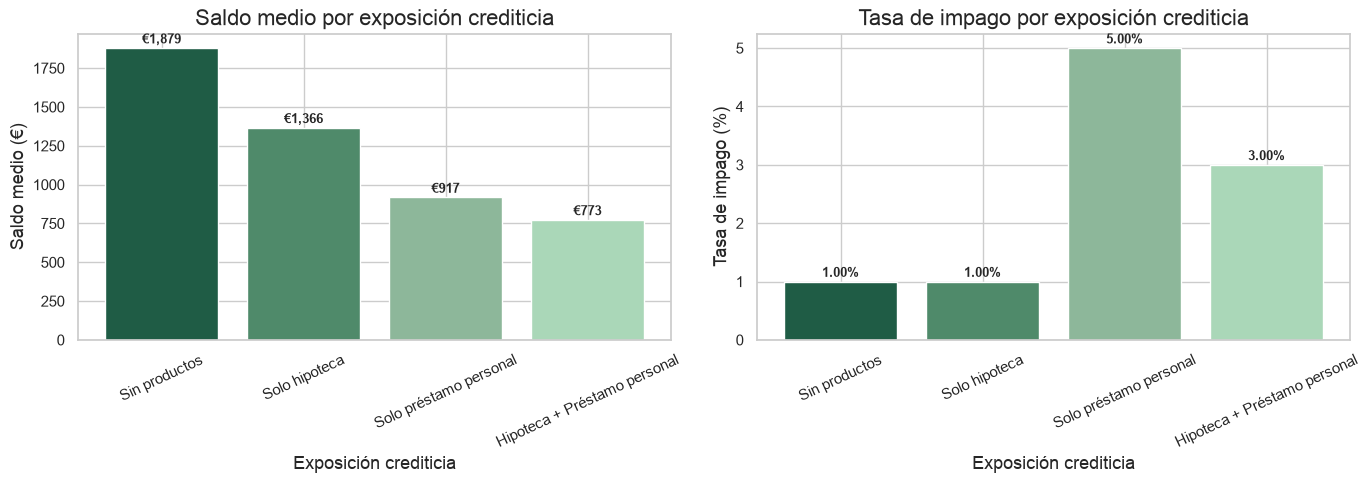

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Saldo medio por exposición crediticia
ax = axes[0]
plot_bal = credit_summary["saldo_medio"]
bars = ax.bar(plot_bal.index, plot_bal.values, color=COLORS[:4])
ax.set_title("Saldo medio por exposición crediticia")
ax.set_xlabel("Exposición crediticia")
ax.set_ylabel("Saldo medio (€)")
ax.tick_params(axis="x", rotation=25)
for bar, val in zip(bars, plot_bal.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 30, f"€{val:,.0f}",
            ha="center", fontsize=9, fontweight="bold")

# Tasa de impago por exposición crediticia
ax = axes[1]
plot_def = credit_summary["tasa_impago_pct"]
bars = ax.bar(plot_def.index, plot_def.values, color=COLORS[:4])
ax.set_title("Tasa de impago por exposición crediticia")
ax.set_xlabel("Exposición crediticia")
ax.set_ylabel("Tasa de impago (%)")
ax.tick_params(axis="x", rotation=25)
for bar, val in zip(bars, plot_def.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.08, f"{val:.2f}%",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


**Hallazgos clave — productos crediticios vs saldo e impago:**

- Los clientes **con cualquier producto crediticio** tienen un saldo medio de **~€1.235** frente a **~€1.879** de quienes **no tienen productos** (−34%).
- **El riesgo de impago aumenta con la complejidad de productos:**
  - Sin productos: **0,87%**
  - Solo hipoteca: **1,40%**
  - Hipoteca + Préstamo personal: **2,69%**
  - Solo préstamo personal: **5,42%** (segmento de mayor riesgo)
- **Se confirman ambas dimensiones:** los clientes con préstamos e hipotecas tienden a tener **saldos más bajos Y mayor riesgo de impago**, especialmente con préstamo personal activo.


## 4. Saldo vs impago crediticio

Comparamos el saldo de la cuenta entre clientes con impago y clientes sin impago.


In [9]:
balance_by_default = (
    df.groupby("default")["balance"]
    .agg(recuento="count", media="mean", mediana="median", std="std")
    .round(2)
)
balance_by_default


,recuento,media,mediana,std
default,,,,
no,10814,1563.13,568.0,3257.85
yes,161,-71.44,0.0,838.73


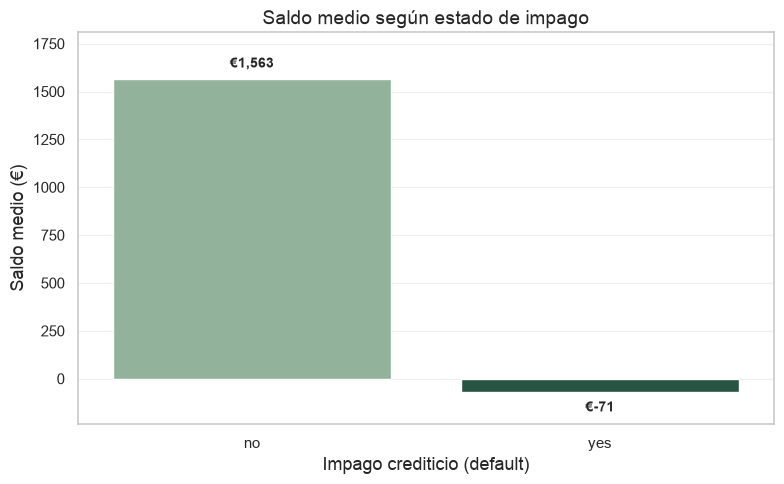

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = balance_by_default["media"]

sns.barplot(
    x=plot_data.index, y=plot_data.values, hue=plot_data.index,
    palette=PALETTE_DEFAULT, legend=False, ax=ax
)
ax.set_title("Saldo medio según estado de impago", fontsize=14)
ax.set_xlabel("Impago crediticio (default)")
ax.set_ylabel("Saldo medio (€)")

offset = plot_data.max() * 0.03
for i, val in enumerate(plot_data.values):
    ax.text(i, val + offset if val >= 0 else val - offset, f"€{val:,.0f}",
            ha="center", va="bottom" if val >= 0 else "top", fontweight="bold", fontsize=10)

ax.grid(axis="y", alpha=0.30)
ax.set_axisbelow(True)
y_min, y_max = plot_data.min(), plot_data.max()
ax.set_ylim(y_min - (y_max - y_min) * 0.10, y_max + (y_max - y_min) * 0.15)
plt.tight_layout()
plt.show()


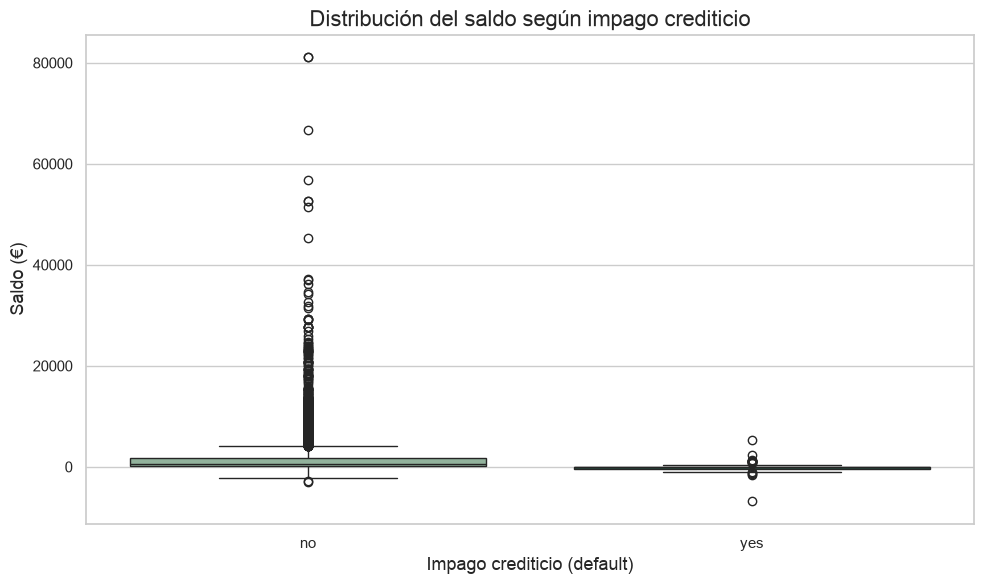

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="default", y="balance", hue="default",
            palette=PALETTE_DEFAULT, legend=False)
plt.title("Distribución del saldo según impago crediticio")
plt.xlabel("Impago crediticio (default)")
plt.ylabel("Saldo (€)")
plt.tight_layout()
plt.show()


**Hallazgo clave:** Los clientes con impago presentan un **saldo medio negativo (~€−71)** y **mediana €0**; los clientes sin impago promedian **~€1.563** (mediana **€568**).


## 5. Tasa de impago por segmento de saldo

Utilizamos tres segmentaciones complementarias de saldo:

1. **Cuartiles** — grupos equilibrados, orientados por los datos
2. **Niveles de negocio estándar** — 5 segmentos (incluyendo > €3.000 como grupo único)
3. **Niveles de negocio extendidos** — 6 segmentos, dividiendo > €3.000 en **€3.000–10.000** y **> €10.000**

> Evaluamos la división extendida porque el segmento > €3.000 muestra impago casi nulo (1 evento en 1.563 clientes). Separar saldos muy elevados (> €10.000) confirma **0% de impago** en esa banda — útil para políticas de vía rápida, aunque aporta poca discriminación adicional de riesgo en la cola superior.


In [12]:
df["balance_quartile"] = pd.qcut(
    df["balance"], q=4,
    labels=["Q1 (más bajo)", "Q2", "Q3", "Q4 (más alto)"]
)

df = assign_balance_tier(df, BALANCE_BINS_STANDARD, BALANCE_LABELS_STANDARD, "balance_tier")
df = assign_balance_tier(df, BALANCE_BINS_EXTENDED, BALANCE_LABELS_EXTENDED, "balance_tier_ext")

quartile_rates = default_rate_table(df, "balance_quartile")
tier_rates = default_rate_table(df, "balance_tier")
tier_ext_rates = default_rate_table(df, "balance_tier_ext")

quartile_rates


,balance_quartile,clientes,impagos,tasa_impago,tasa_impago_pct
0,Q1 (más bajo),2749,132,0.048017,4.80
1,Q2,2741,17,0.006202,0.62
2,Q3,2742,10,0.003647,0.36
3,Q4 (más alto),2743,2,0.000729,0.07


In [13]:
tier_rates


,balance_tier,clientes,impagos,tasa_impago,tasa_impago_pct
0,Negativo (≤ €0),1426,100,0.070126,7.01
1,€0–500,3812,49,0.012854,1.29
2,€500–1.500,2658,10,0.003762,0.38
3,€1.500–3.000,1516,1,0.000660,0.07
4,> €3.000,1563,1,0.000640,0.06


In [14]:
tier_ext_rates


,balance_tier_ext,clientes,impagos,tasa_impago,tasa_impago_pct
0,Negativo (≤ €0),1426,100,0.070126,7.01
1,€0–500,3812,49,0.012854,1.29
2,€500–1.500,2658,10,0.003762,0.38
3,€1.500–3.000,1516,1,0.000660,0.07
4,€3.000–10.000,1336,1,0.000749,0.07
5,> €10.000,227,0,0.000000,0.00


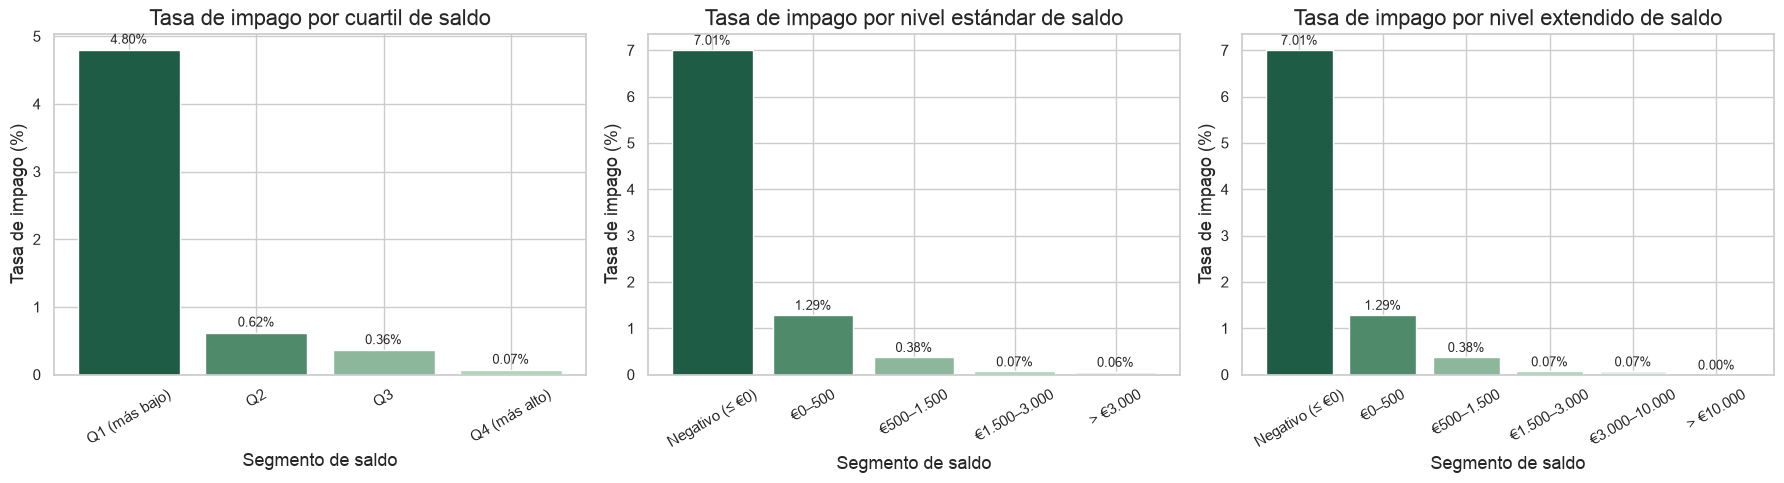

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, table, title, n_colors in [
    (axes[0], quartile_rates, "Tasa de impago por cuartil de saldo", 4),
    (axes[1], tier_rates, "Tasa de impago por nivel estándar de saldo", 5),
    (axes[2], tier_ext_rates, "Tasa de impago por nivel extendido de saldo", 6),
]:
    group_col = table.columns[0]
    bars = ax.bar(
        table[group_col].astype(str), table["tasa_impago_pct"],
        color=COLORS[:n_colors] if n_colors <= len(COLORS) else COLORS
    )
    ax.set_title(title)
    ax.set_xlabel("Segmento de saldo")
    ax.set_ylabel("Tasa de impago (%)")
    ax.tick_params(axis="x", rotation=30)
    for bar, rate in zip(bars, table["tasa_impago_pct"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{rate:.2f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


### Conclusiones por segmento de saldo

| Segmentación | Segmento de mayor riesgo | Tasa impago | Segmento de menor riesgo | Tasa impago |
|---|---|---:|---|---:|
| Cuartil (Q1 vs Q4) | Q1 (más bajo) | ~4,8% | Q4 (más alto) | ~0,07% |
| Niveles estándar | Negativo (≤ €0) | ~7,0% | > €3.000 | ~0,06% |
| Niveles extendidos | Negativo (≤ €0) | ~7,0% | > €10.000 | 0,00% |

La **división extendida** confirma que el riesgo ya es mínimo por encima de €3.000; las bandas €3k–10k y > €10k muestran impago negligible. **Recomendación operativa:** mantener 5 niveles estándar para reglas de política; usar la división en 6 niveles solo para validar elegibilidad de vía rápida en clientes de alto saldo.


## 6. Análisis binario de saldo (≤ €500 vs > €500)

Mantenemos la división binaria como regla operativa simple, cruzándola con `loan`, `housing` y la exposición crediticia.


In [16]:
df["balance_level"] = np.where(df["balance"] <= 500, "Saldo bajo (≤ €500)", "Saldo alto (> €500)")

loan_rate, loan_n = cross_default_rate(df, "balance_level", "loan")
print("Tasa de impago — Nivel de saldo × Préstamo personal (loan)")
display((loan_rate * 100).round(2).astype(str) + "%")
print("\nTamaños muestrales:")
display(loan_n.astype(int))


Tasa de impago — Nivel de saldo × Préstamo personal (loan)


loan,no,yes
balance_level,,
Saldo alto (> €500),0.17%,0.53%
Saldo bajo (≤ €500),2.22%,6.03%



Tamaños muestrales:


loan,no,yes
balance_level,,
Saldo alto (> €500),5173,564
Saldo bajo (≤ €500),4375,863


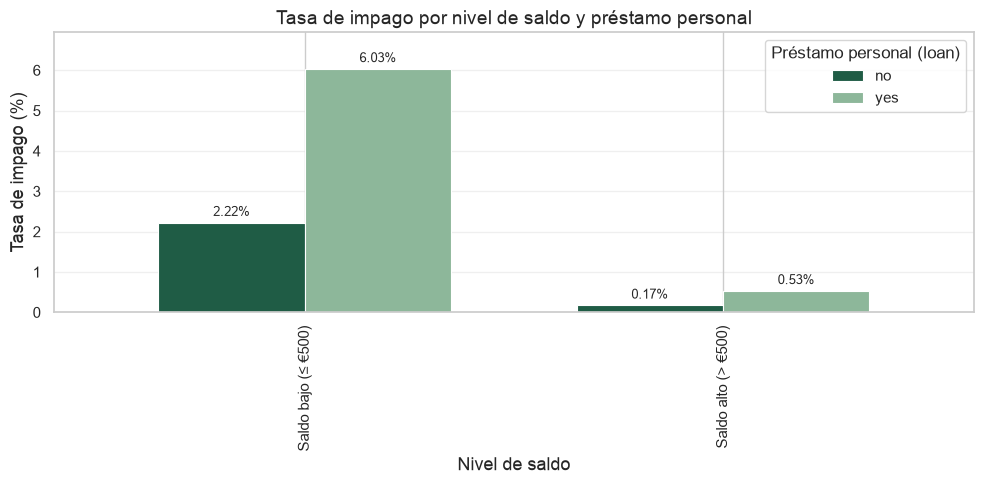

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
loan_rate_pct = (loan_rate * 100).round(2).reindex(["Saldo bajo (≤ €500)", "Saldo alto (> €500)"])
loan_rate_pct.plot(kind="bar", ax=ax, color=["#1F5C45", "#8DB79A"],
                   edgecolor="white", linewidth=0.8, width=0.70)
ax.set_title("Tasa de impago por nivel de saldo y préstamo personal", fontsize=14)
ax.set_xlabel("Nivel de saldo")
ax.set_ylabel("Tasa de impago (%)")
ax.grid(axis="y", alpha=0.30)
ax.set_axisbelow(True)
ax.legend(title="Préstamo personal (loan)", labels=["no", "yes"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", fontsize=9, padding=3)
ax.set_ylim(0, loan_rate_pct.max().max() * 1.15)
plt.tight_layout()
plt.show()


In [18]:
housing_rate, housing_n = cross_default_rate(df, "balance_level", "housing")
print("Tasa de impago — Nivel de saldo × Hipoteca (housing)")
display((housing_rate * 100).round(2).astype(str) + "%")


Tasa de impago — Nivel de saldo × Hipoteca (housing)


housing,no,yes
balance_level,,
Saldo alto (> €500),0.16%,0.28%
Saldo bajo (≤ €500),2.84%,2.85%


In [19]:
exposure_binary_rate, exposure_binary_n = cross_default_rate(df, "balance_level", "credit_exposure")
exposure_binary_rate = exposure_binary_rate.reindex(columns=CREDIT_EXPOSURE_ORDER)
exposure_binary_n = exposure_binary_n.reindex(columns=CREDIT_EXPOSURE_ORDER)

print("Tasa de impago — Nivel de saldo binario × Exposición crediticia")
display((exposure_binary_rate * 100).round(2).astype(str) + "%")
print("\nTamaños muestrales:")
display(exposure_binary_n.astype(int))


Tasa de impago — Nivel de saldo binario × Exposición crediticia


credit_exposure,Sin productos,Solo hipoteca,Solo préstamo personal,Hipoteca + Préstamo personal
balance_level,,,,
Saldo alto (> €500),0.1%,0.27%,0.86%,0.3%
Saldo bajo (≤ €500),1.91%,2.52%,8.22%,4.32%



Tamaños muestrales:


credit_exposure,Sin productos,Solo hipoteca,Solo préstamo personal,Hipoteca + Préstamo personal
balance_level,,,,
Saldo alto (> €500),2989,2184,232,332
Saldo bajo (≤ €500),2196,2179,377,486


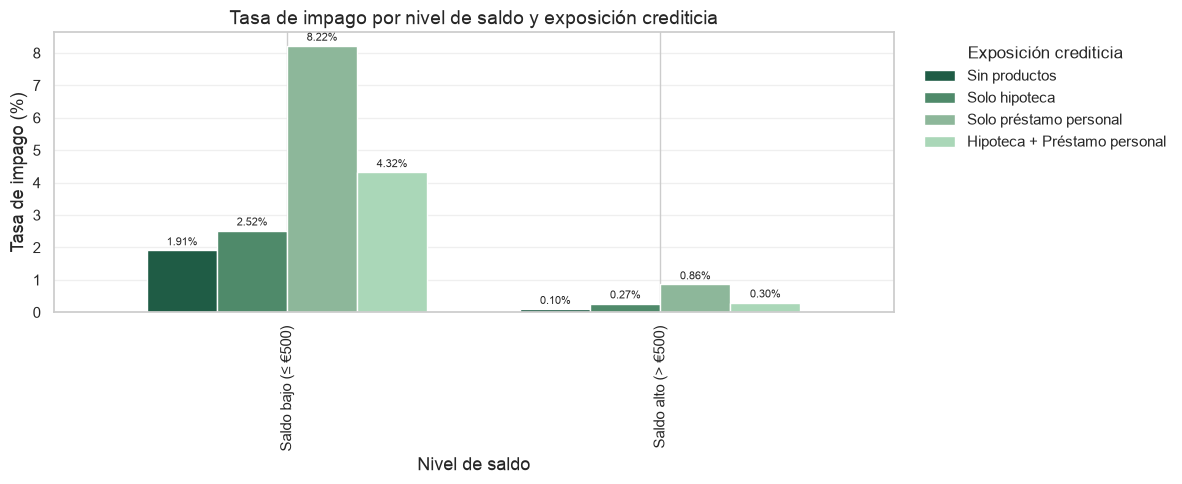

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_data = (exposure_binary_rate * 100).round(2).reindex(["Saldo bajo (≤ €500)", "Saldo alto (> €500)"])
plot_data.plot(kind="bar", ax=ax, color=COLORS[:4], edgecolor="white", width=0.75)
ax.set_title("Tasa de impago por nivel de saldo y exposición crediticia", fontsize=14)
ax.set_xlabel("Nivel de saldo")
ax.set_ylabel("Tasa de impago (%)")
ax.legend(title="Exposición crediticia", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.grid(axis="y", alpha=0.30)
ax.set_axisbelow(True)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", fontsize=8, padding=2)
plt.tight_layout()
plt.show()


**Conclusiones del análisis binario:**

- **Saldo bajo + solo préstamo personal: ~8,2%** de impago — el segmento accionable de mayor riesgo.
- **Saldo bajo + hipoteca + préstamo personal: ~4,3%**.
- Los clientes con saldo alto se mantienen por debajo del **1%** de impago en todos los tipos de exposición.
- La división binaria es eficaz para **reglas automatizadas**; los niveles granulares (Sección 7) refinan los umbrales de política.


## 7. Niveles extendidos de saldo × Exposición crediticia

Segmentación de 6 niveles de saldo cruzada con exposición crediticia — la vista más granular para diseño de políticas basadas en riesgo.


In [21]:
tier_ext_exposure_rate, tier_ext_exposure_n = cross_default_rate(df, "balance_tier_ext", "credit_exposure")
tier_ext_exposure_rate = tier_ext_exposure_rate.reindex(columns=CREDIT_EXPOSURE_ORDER)

print("Tasa de impago (%) — Nivel extendido de saldo × Exposición crediticia")
display((tier_ext_exposure_rate * 100).round(2).astype(str) + "%")


Tasa de impago (%) — Nivel extendido de saldo × Exposición crediticia


credit_exposure,Sin productos,Solo hipoteca,Solo préstamo personal,Hipoteca + Préstamo personal
balance_tier_ext,,,,
Negativo (≤ €0),4.47%,6.6%,19.33%,6.97%
€0–500,1.22%,0.84%,3.1%,2.46%
€500–1.500,0.24%,0.37%,1.53%,0.5%
€1.500–3.000,0.0%,0.19%,0.0%,0.0%
€3.000–10.000,0.0%,0.2%,0.0%,0.0%
> €10.000,0.0%,0.0%,0.0%,0.0%


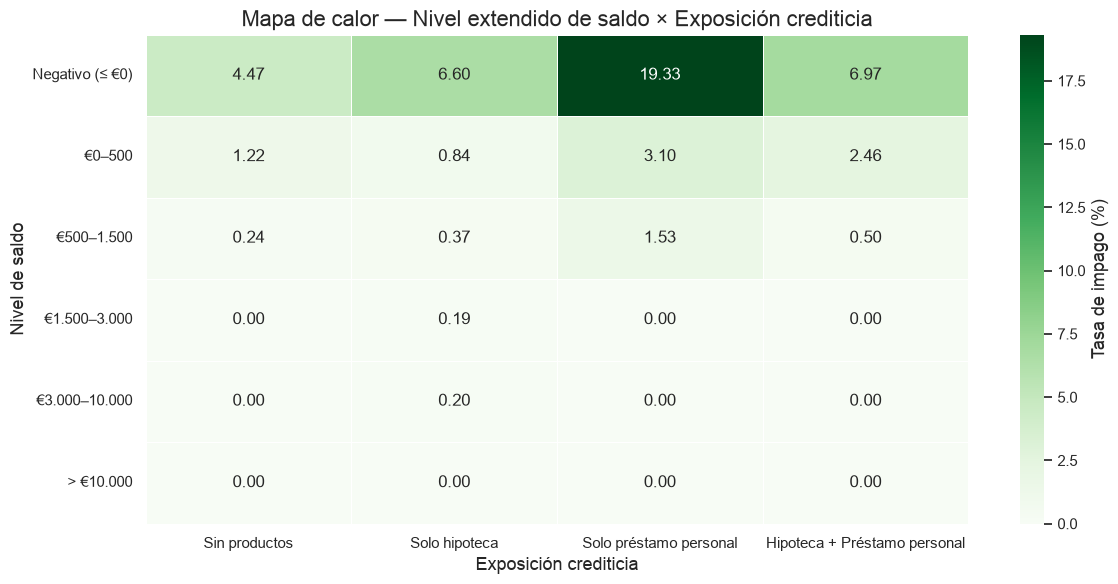

In [22]:
# Mapa de calor de tasas de impago
heatmap_data = (tier_ext_exposure_rate * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt=".2f", cmap="Greens",
    linewidths=0.5, linecolor="white", cbar_kws={"label": "Tasa de impago (%)"}, ax=ax
)
ax.set_title("Mapa de calor — Nivel extendido de saldo × Exposición crediticia")
ax.set_xlabel("Exposición crediticia")
ax.set_ylabel("Nivel de saldo")
plt.tight_layout()
plt.show()


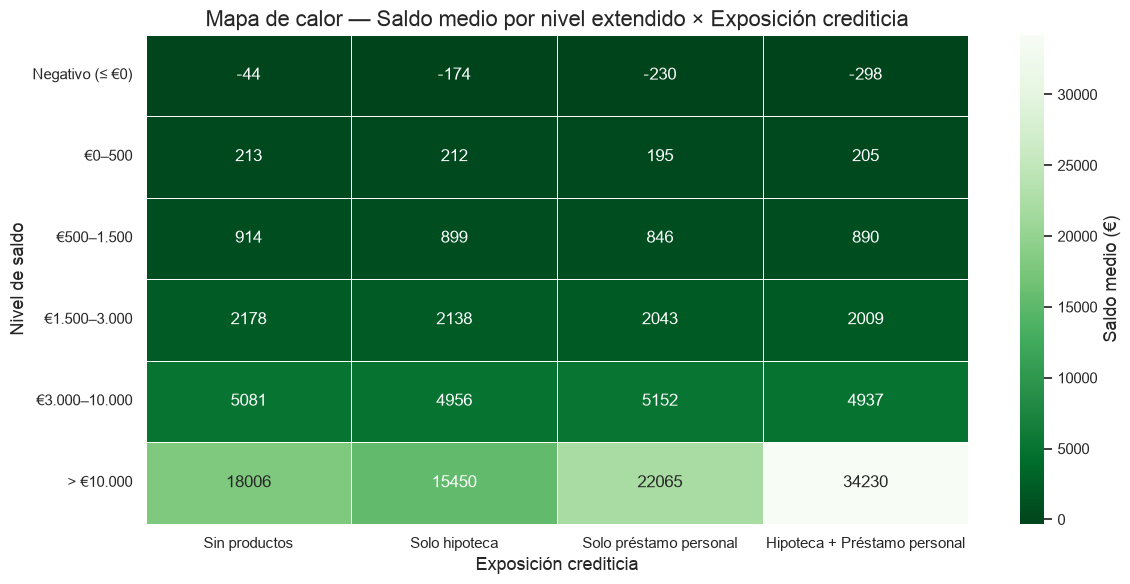

In [23]:
# Mapa de calor de saldo medio (contexto)
balance_heatmap = (
    df.groupby(["balance_tier_ext", "credit_exposure"], observed=True)["balance"]
    .mean()
    .unstack()
    .reindex(columns=CREDIT_EXPOSURE_ORDER)
    .round(0)
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    balance_heatmap, annot=True, fmt=".0f", cmap="Greens_r",
    linewidths=0.5, linecolor="white", cbar_kws={"label": "Saldo medio (€)"}, ax=ax
)
ax.set_title("Mapa de calor — Saldo medio por nivel extendido × Exposición crediticia")
ax.set_xlabel("Exposición crediticia")
ax.set_ylabel("Nivel de saldo")
plt.tight_layout()
plt.show()


**Conclusiones de niveles extendidos:**

- **Saldo negativo + solo préstamo personal → ~19%** de impago (segmento pequeño pero crítico).
- **Saldo negativo + ambos productos → ~7%** de impago.
- A partir de **€500–1.500**, las tasas de impago caen por debajo del **1,5%** en todos los tipos de exposición.
- **> €10.000** muestra **0% de impago** en todos los perfiles de exposición (227 clientes, 0 impagos).
- **Segmentos operativos recomendados:** Negativo (≤ €0), €0–500, €500–1.500, €1.500–3.000, > €3.000 (5 niveles). La división €3k/€10k es informativa pero no cambia la acción de política.


## 8. Interacciones adicionales de riesgo

Segmentaciones transformadas del notebook de Transformaciones de Datos: `age_group`, `job_profile` y `financial_burden_label` (esquema Semana 2: **No / Low / High burden** según hipoteca + préstamo personal).


In [24]:
age_rate, age_n = cross_default_rate(df, "balance_level", "age_group")
age_order = sorted(age_rate.columns, key=lambda x: int(re.search(r"\d+", str(x)).group()))
age_rate = age_rate.reindex(columns=age_order)

print("Tasa de impago — Nivel de saldo × Grupo de edad (age_group)")
display((age_rate * 100).round(2).astype(str) + "%")


Tasa de impago — Nivel de saldo × Grupo de edad (age_group)


age_group,Young (18-25),Young Adult (26-35),Adult (36-50),Middle-Aged (51-65),Senior (65+)
balance_level,,,,,
Saldo alto (> €500),0.0%,0.11%,0.18%,0.43%,0.34%
Saldo bajo (≤ €500),0.87%,2.66%,3.57%,2.42%,0.0%


In [25]:
low_balance = df[df["balance"] <= 500]

job_risk = (
    low_balance.groupby("job_profile")
    .agg(clientes=("default_flag", "count"),
         impagos=("default_flag", "sum"),
         tasa_impago=("default_flag", "mean"))
    .query("clientes >= 5")
    .sort_values("tasa_impago", ascending=False)
)
job_risk["tasa_impago_pct"] = (job_risk["tasa_impago"] * 100).round(2)
job_risk


,clientes,impagos,tasa_impago,tasa_impago_pct
job_profile,,,,
Self-Employed,354,17,0.048023,4.80
Unemployed,151,7,0.046358,4.64
Unknown,27,1,0.037037,3.70
Blue Collar,1626,50,0.030750,3.08
White Collar,2648,69,0.026057,2.61
Retired,253,4,0.015810,1.58
Student,179,1,0.005587,0.56


/var/folders/6f/lhr87vh51bq38sm9v46389m00000gn/T/ipykernel_88147/1038318375.py:3: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=plot_jobs, x="tasa_impago_pct", y="job_profile", hue="job_profile",


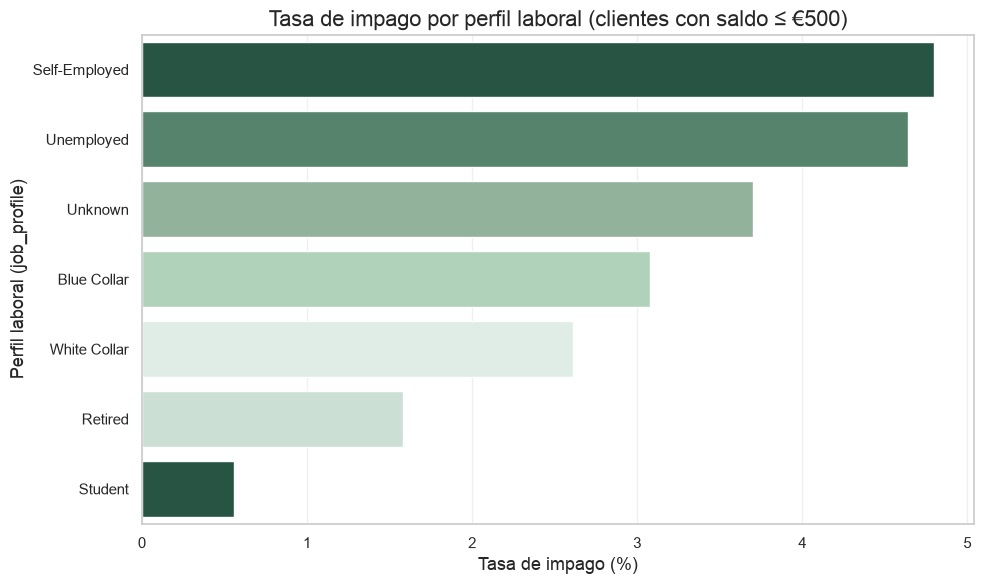

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_jobs = job_risk.head(8).reset_index()
sns.barplot(data=plot_jobs, x="tasa_impago_pct", y="job_profile", hue="job_profile",
            palette=COLORS, legend=False, ax=ax)
ax.set_title("Tasa de impago por perfil laboral (clientes con saldo ≤ €500)")
ax.set_xlabel("Tasa de impago (%)")
ax.set_ylabel("Perfil laboral (job_profile)")
ax.grid(axis="x", alpha=0.30)
plt.tight_layout()
plt.show()


### Saldo × Carga financiera (`financial_burden_label`) — transformación actualizada

En la Semana 2, `financial_burden_label` se mapea directamente a productos crediticios:

| Valor en dataset | Significado |
|---|---|
| No burden | Sin hipoteca ni préstamo personal |
| Low burden | Hipoteca **o** préstamo personal (un producto) |
| High burden | Hipoteca **y** préstamo personal (ambos) |


In [27]:
burden_rate, burden_n = cross_default_rate(df, "balance_level", "financial_burden_label")
burden_order = ["No burden", "Low burden", "High burden"]
burden_rate = burden_rate.reindex(columns=burden_order)

print("Tasa de impago — Nivel de saldo × Carga financiera (financial_burden_label)")
display((burden_rate * 100).round(2).astype(str) + "%")


Tasa de impago — Nivel de saldo × Carga financiera (financial_burden_label)


financial_burden_label,No burden,Low burden,High burden
balance_level,,,
Saldo alto (> €500),0.1%,0.33%,0.3%
Saldo bajo (≤ €500),1.91%,3.36%,4.32%


In [28]:
row_order = ["Saldo bajo (≤ €500)", "Saldo alto (> €500)"]
column_order = ["No burden", "Low burden", "High burden"]

burden_distribution = (
    pd.crosstab(df["balance_level"], df["financial_burden_label"], normalize="index") * 100
).round(2).reindex(index=row_order, columns=column_order)

burden_counts = pd.crosstab(df["balance_level"], df["financial_burden_label"]).reindex(
    index=row_order, columns=column_order
)

print("Distribución de carga financiera dentro de cada nivel de saldo")
display(burden_distribution.astype(str) + "%")
print("\nTamaños muestrales")
display(burden_counts)


Distribución de carga financiera dentro de cada nivel de saldo


financial_burden_label,No burden,Low burden,High burden
balance_level,,,
Saldo bajo (≤ €500),41.92%,48.8%,9.28%
Saldo alto (> €500),52.1%,42.11%,5.79%



Tamaños muestrales


financial_burden_label,No burden,Low burden,High burden
balance_level,,,
Saldo bajo (≤ €500),2196,2556,486
Saldo alto (> €500),2989,2416,332


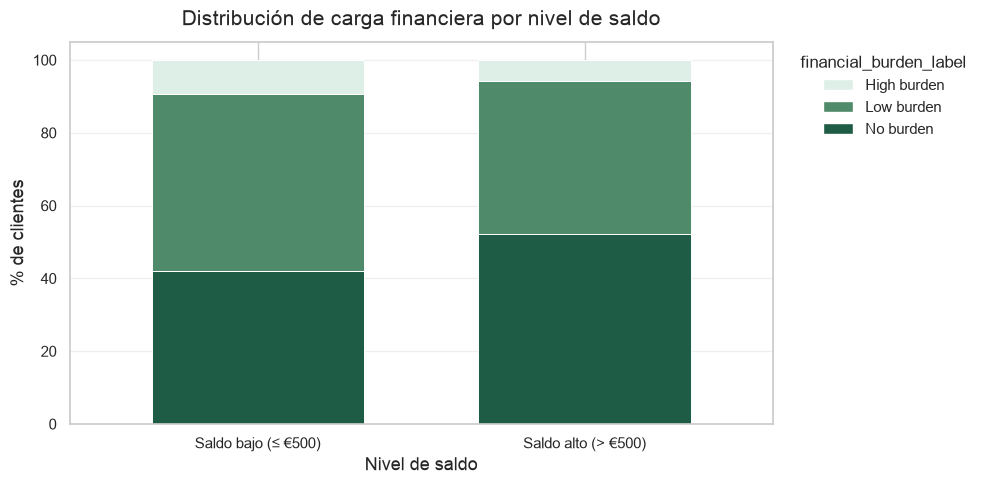

In [29]:
burden_distribution_plot = burden_distribution.reindex(index=["Saldo bajo (≤ €500)", "Saldo alto (> €500)"])
colors_burden = ["#1F5C45", "#4F8A6A", "#DDEFE6"]

fig, ax = plt.subplots(figsize=(10, 5))
burden_distribution_plot[column_order].plot(
    kind="bar", stacked=True, color=colors_burden,
    edgecolor="white", linewidth=0.7, width=0.65, ax=ax
)
ax.set_title("Distribución de carga financiera por nivel de saldo", fontsize=15, pad=12)
ax.set_xlabel("Nivel de saldo")
ax.set_ylabel("% de clientes")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.30)
ax.set_axisbelow(True)

legend_handles = [
    Patch(facecolor="#DDEFE6", label="High burden"),
    Patch(facecolor="#4F8A6A", label="Low burden"),
    Patch(facecolor="#1F5C45", label="No burden"),
]
ax.legend(handles=legend_handles, title="financial_burden_label",
          bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


**Conclusiones de la sección 8:**

- Saldo bajo + **High burden** (ambos productos): **~4,3%** de impago.
- Saldo bajo + **Low burden** (un producto): **~3,4%**.
- Los perfiles **Self-Employed** y **Blue Collar** siguen siendo los de mayor riesgo entre clientes con saldo bajo.


## 9. Análisis complementario — Clusters de clientes

> **Nota:** Los clusters se construyeron a partir de **variables de identidad** (edad, perfil laboral, educación, estado civil) para segmentación de **Perfil de Cliente** — no a partir de saldo o impago. Incluimos este análisis para explorar si los clusters aportan valor en la **personalización de ofertas**, reconociendo que **saldo + exposición crediticia siguen siendo los principales drivers de riesgo**.

Dataset: `2026-07-06_bank_dataset_clustered.csv`


In [30]:
df_cluster = pd.read_csv(CLUSTERED_PATH)
df_cluster["default_flag"] = (df_cluster["default"] == "yes").astype(int)
df_cluster["credit_exposure"] = assign_credit_exposure(df_cluster)

print(f"Registros en el dataset clusterizado: {len(df_cluster):,}")
print(f"\nDistribución de clusters (segment_label):")
print(df_cluster["segment_label"].value_counts())


Registros en el dataset clusterizado: 10,975

Distribución de clusters (segment_label):
segment_label
Joves solters                      2701
Adults consolidats                 2645
Treballadors manuals               2292
Professionals estudis superiors    2210
Jubilats                            769
Estudiants                          358
Name: count, dtype: int64


In [31]:
cluster_summary = (
    df_cluster.groupby("segment_label")
    .agg(
        clientes=("default_flag", "count"),
        impagos=("default_flag", "sum"),
        tasa_impago=("default_flag", "mean"),
        saldo_medio=("balance", "mean"),
    )
    .sort_values("tasa_impago", ascending=False)
    .round(2)
)
cluster_summary["tasa_impago_pct"] = (cluster_summary["tasa_impago"] * 100).round(2)
cluster_summary


,clientes,impagos,tasa_impago,saldo_medio,tasa_impago_pct
segment_label,,,,,
Joves solters,2701,45,0.02,1259.13,2.0
Treballadors manuals,2292,38,0.02,1198.88,2.0
Adults consolidats,2645,43,0.02,1781.78,2.0
Professionals estudis superiors,2210,29,0.01,1639.76,1.0
Jubilats,769,5,0.01,2427.64,1.0
Estudiants,358,1,0.00,1508.10,0.0


In [32]:
cluster_exposure_rate, _ = cross_default_rate(df_cluster, "segment_label", "credit_exposure")
cluster_exposure_rate = cluster_exposure_rate.reindex(columns=CREDIT_EXPOSURE_ORDER)

print("Tasa de impago (%) — Cluster (segment_label) × Exposición crediticia")
display((cluster_exposure_rate * 100).round(2).astype(str) + "%")


Tasa de impago (%) — Cluster (segment_label) × Exposición crediticia


credit_exposure,Sin productos,Solo hipoteca,Solo préstamo personal,Hipoteca + Préstamo personal
segment_label,,,,
Adults consolidats,1.21%,1.63%,4.59%,1.66%
Estudiants,0.33%,0.0%,0.0%,NaN
Joves solters,0.87%,1.91%,4.82%,2.14%
Jubilats,0.32%,1.02%,6.25%,0.0%
Professionals estudis superiors,0.66%,1.01%,7.07%,3.75%
Treballadors manuals,1.23%,1.11%,6.09%,3.36%


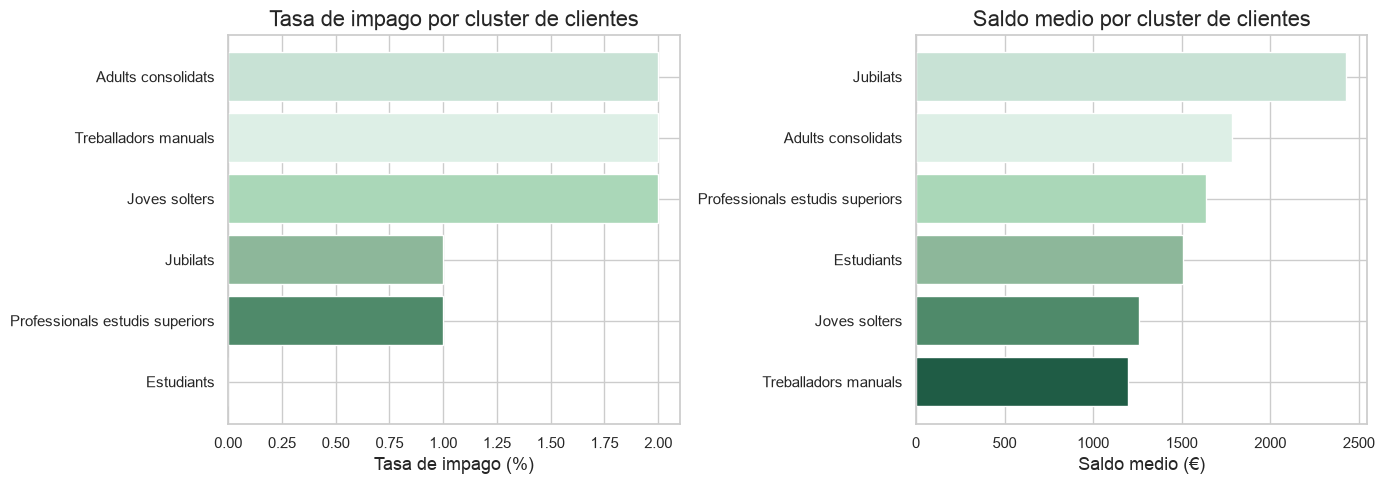

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
plot = cluster_summary["tasa_impago_pct"].sort_values(ascending=True)
ax.barh(plot.index, plot.values, color=COLORS[:len(plot)])
ax.set_title("Tasa de impago por cluster de clientes")
ax.set_xlabel("Tasa de impago (%)")

ax = axes[1]
plot_bal = cluster_summary["saldo_medio"].sort_values(ascending=True)
ax.barh(plot_bal.index, plot_bal.values, color=COLORS[:len(plot_bal)])
ax.set_title("Saldo medio por cluster de clientes")
ax.set_xlabel("Saldo medio (€)")

plt.tight_layout()
plt.show()


**Conclusión del análisis por clusters:**

- Los clusters muestran **diferencias moderadas** en tasa de impago (0,3%–1,7%) frente a segmentos **saldo × exposición** (hasta **19%**).
- **Joves solters** y **Treballadors manuals** presentan ligeramente mayor impago y saldos más bajos.
- **Recomendación:** Usar clusters para **comunicación y personalización de ofertas** (equipo Perfil de Cliente); usar **niveles de saldo + exposición crediticia** para **decisiones de riesgo crediticio** (equipo Finanzas y Riesgo Crediticio).


## 10. Validación estadística


In [34]:
# Mann-Whitney U — saldo: clientes con impago vs sin impago
balance_default = df.loc[df["default"] == "yes", "balance"]
balance_no_default = df.loc[df["default"] == "no", "balance"]
u_stat, u_pvalue = stats.mannwhitneyu(balance_default, balance_no_default, alternative="two-sided")

print("Mann-Whitney U — saldo según estado de impago (default)")
print(f"  Estadístico U : {u_stat:,.1f}")
print(f"  p-valor       : {u_pvalue:.2e}")
print(f"  Conclusión    : {'Rechazar H₀' if u_pvalue < 0.05 else 'No rechazar H₀'}")


Mann-Whitney U — saldo según estado de impago (default)
  Estadístico U : 253,008.0
  p-valor       : 4.97e-54
  Conclusión    : Rechazar H₀


In [35]:
# Mann-Whitney U — saldo: con vs sin productos crediticios
has_products = df[df["credit_exposure"] != "Sin productos"]["balance"]
no_products = df[df["credit_exposure"] == "Sin productos"]["balance"]
u_stat2, u_pvalue2 = stats.mannwhitneyu(has_products, no_products, alternative="two-sided")

print("Mann-Whitney U — saldo: con productos crediticios vs sin productos")
print(f"  Estadístico U : {u_stat2:,.1f}")
print(f"  p-valor       : {u_pvalue2:.2e}")
print(f"  Conclusión    : {'Rechazar H₀ — los saldos difieren significativamente' if u_pvalue2 < 0.05 else 'No rechazar H₀'}")


Mann-Whitney U — saldo: con productos crediticios vs sin productos
  Estadístico U : 12,516,258.0
  p-valor       : 3.21e-51
  Conclusión    : Rechazar H₀ — los saldos difieren significativamente


In [36]:
# Chi-cuadrado — exposición crediticia vs impago
contingency_exposure = pd.crosstab(df["credit_exposure"], df["default_flag"])
chi2_e, chi_p_e, dof_e, _ = stats.chi2_contingency(contingency_exposure)

print("Chi-cuadrado — exposición crediticia vs impago")
print(f"  Estadístico χ² : {chi2_e:.2f}")
print(f"  gl             : {dof_e}")
print(f"  p-valor        : {chi_p_e:.2e}")
print(f"  Conclusión     : {'Rechazar H₀ — exposición e impago están asociados' if chi_p_e < 0.05 else 'No rechazar H₀'}")
display(contingency_exposure)


Chi-cuadrado — exposición crediticia vs impago
  Estadístico χ² : 87.27
  gl             : 3
  p-valor        : 8.45e-19
  Conclusión     : Rechazar H₀ — exposición e impago están asociados


default_flag,0,1
credit_exposure,,
Hipoteca + Préstamo personal,796,22
Sin productos,5140,45
Solo hipoteca,4302,61
Solo préstamo personal,576,33


In [37]:
# Chi-cuadrado — cuartil de saldo vs impago
contingency = pd.crosstab(df["balance_quartile"], df["default_flag"])
chi2, chi_p, dof, _ = stats.chi2_contingency(contingency)

print("Chi-cuadrado — cuartil de saldo vs impago")
print(f"  Estadístico χ² : {chi2:.2f}")
print(f"  p-valor        : {chi_p:.2e}")


Chi-cuadrado — cuartil de saldo vs impago
  Estadístico χ² : 285.02
  p-valor        : 1.73e-61


In [38]:
# Odds ratios
with_products = df[df["credit_exposure"] != "Sin productos"]
without_products = df[df["credit_exposure"] == "Sin productos"]

product_comparison = odds_ratio_and_rr(
    with_products, without_products,
    label_a="Con productos crediticios", label_b="Sin productos crediticios"
)
product_comparison


,comparacion,tasa_impago_Con productos crediticios,tasa_impago_Sin productos crediticios,odds_ratio,riesgo_relativo
0,Con productos crediticios vs Sin productos cre...,2.00%,0.87%,2.34,2.31


In [39]:
personal_loan_only = df[df["credit_exposure"] == "Solo préstamo personal"]
no_products = df[df["credit_exposure"] == "Sin productos"]

loan_comparison = odds_ratio_and_rr(
    personal_loan_only, no_products,
    label_a="Solo préstamo personal", label_b="Sin productos"
)
loan_comparison


,comparacion,tasa_impago_Solo préstamo personal,tasa_impago_Sin productos,odds_ratio,riesgo_relativo
0,Solo préstamo personal vs Sin productos,5.42%,0.87%,6.54,6.24


In [40]:
q1 = df[df["balance_quartile"] == "Q1 (más bajo)"]
q4 = df[df["balance_quartile"] == "Q4 (más alto)"]

quartile_comparison = odds_ratio_and_rr(
    q1, q4, label_a="Q1 (saldo más bajo)", label_b="Q4 (saldo más alto)"
)
quartile_comparison


,comparacion,tasa_impago_Q1 (saldo más bajo),tasa_impago_Q4 (saldo más alto),odds_ratio,riesgo_relativo
0,Q1 (saldo más bajo) vs Q4 (saldo más alto),4.80%,0.07%,69.13,65.86


**Resumen estadístico:**

- Las distribuciones de saldo difieren significativamente entre clientes con y sin impago (Mann-Whitney, p ≈ 5 × 10⁻⁵⁴).
- Los clientes con productos crediticios tienen **saldos significativamente más bajos** que quienes no los tienen (Mann-Whitney, p ≈ 10⁻⁵⁰).
- La exposición crediticia está **asociada al impago** (Chi-cuadrado, p ≈ 10⁻¹⁵).
- Clientes con **solo préstamo personal** tienen **~6× más probabilidad** de impago que quienes no tienen productos.
- El **riesgo relativo Q1 vs Q4** de cuartil de saldo se mantiene en **~65×**.


## 11. Recomendaciones de política crediticia y ofertas


| # | Política / Oferta | Condición de activación | Acción recomendada | Justificación |
|---|---|---|---|---|
| **1** | **Revisión de préstamo personal** | Solo préstamo personal (cualquier saldo) | Revisión obligatoria por analista de crédito antes de nuevo crédito | 5,4% impago — grupo de mayor exposición |
| **2** | **Alerta de productos combinados** | Hipoteca + Préstamo personal + saldo ≤ €500 | Restringir nuevo crédito; exigir plan de reestructuración | ~4,3% impago en segmento de saldo bajo |
| **3** | **Bloqueo por saldo negativo** | Saldo ≤ €0 | Bloquear aprobación automatizada | ~7,0% impago |
| **4** | **Límite de crédito reducido** | Saldo €0–500 + cualquier producto crediticio | Limitar nuevo crédito al 50% del estándar | 2,5–8,2% impago según exposición |
| **5** | **Precios según producto** | Low burden + saldo bajo | Precio basado en riesgo en ofertas de préstamo personal | ~3,4% impago entre clientes de saldo bajo |
| **6** | **Revisión por ocupación** | Saldo ≤ €500 + Self-Employed / Blue Collar | Chequeo de salud financiera pre-aprobación | Impago elevado en segmento de saldo bajo |
| **7** | **Outreach preventivo** | Cuartil Q1 + Low/High burden | Asesoramiento financiero proactivo | Intervención temprana antes del impago |
| **8** | **Aprobación vía rápida** | Saldo > €3.000 + Sin productos | Proceso de aprobación ágil | ~0,06% impago |
| **9** | **Ofertas por cluster** | Clusters de Perfil de Cliente (p. ej. Joves solters) | Personalizar comunicación y productos de ahorro — **no** límites de crédito | Clusters útiles para ofertas, no señal principal de riesgo |


## 12. Conclusiones de negocio

### Respuesta directa a la pregunta de negocio

**1. ¿Los clientes con préstamos e hipotecas tienen saldos más bajos?**

**Sí.** Los clientes con cualquier producto crediticio promedian **~€1.235** frente a **~€1.879** de quienes no tienen productos (−34%). El efecto es más intenso en **solo préstamo personal** (media **~€917**) e **hipoteca + préstamo personal** (media **~€773**).

**2. ¿Tienen mayor riesgo de impago?**

**Sí.** Las tasas de impago aumentan con la complejidad de productos: **0,87%** (sin productos) → **1,40%** (solo hipoteca) → **2,69%** (ambos) → **5,42%** (solo préstamo personal). Combinado con **saldo bajo (≤ €500)**, el solo préstamo personal alcanza **~8,2%** de impago.

**3. ¿Cómo ajustar ofertas y estrategias de riesgo?**

- Incorporar el **perfil de exposición crediticia** (hipoteca / préstamo / ambos) como **input obligatorio** junto al saldo en el scoring crediticio.
- Aplicar **controles más estrictos** a titulares de préstamo personal — especialmente con saldo bajo.
- Usar **5 niveles estándar de saldo** para reglas operativas; la división €3k/€10k confirma elegibilidad de vía rápida pero no añade nueva acción de riesgo.
- Usar **clusters** para personalización de ofertas (equipo Perfil de Cliente), no como señal principal de riesgo crediticio.
- Reservar **aprobación vía rápida** para saldo > €3.000 sin productos crediticios activos.

### Limitaciones

- **Desequilibrio de clases:** 161 impagos en 10.975 registros — segmentos pequeños (p. ej. saldo negativo + solo préstamo personal) requieren interpretación cautelosa.
- **Datos observacionales:** Asociación, no causalidad — el saldo bajo puede reflejar estrés financiero previo.
- **Clusters:** Construidos sobre variables de identidad; la discriminación de riesgo es menor que saldo + exposición crediticia.

---

*Notebook preparado por Equip_32 — Analistas de Finanzas y Riesgo Crediticio. Análisis Semana 2.*
